# 01 - Análisis Exploratorio de Datos CNE

Este notebook realiza un análisis exploratorio de datos de precios de combustibles obtenidos desde la API de la CNE.

El objetivo es revisar la calidad del dataset, detectar valores atípicos, documentar reglas de limpieza y generar insumos útiles para una aplicación en Streamlit.

## Objetivos del EDA

- Revisar dimensiones, columnas y tipos de datos.
- Validar valores faltantes, duplicados, fechas y coordenadas.
- Detectar precios imposibles o sospechosos.
- Documentar una regla reproducible para corregir errores de digitación decimal.
- Construir un dataset limpio para la aplicación.
- Identificar análisis útiles para el dashboard: filtros, rankings, mapas y oportunidades de ahorro.

> Nota: aunque el archivo de entrada se llama `dataset_limpio.csv`, en este notebook se realiza una revisión adicional de calidad y se vuelve a exportar el archivo corregido.

## 1. Librerías y configuración

Se cargan las librerías necesarias para análisis tabular y visualización. También se configuran opciones de visualización para que las tablas se lean mejor dentro del notebook.

In [86]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

## 2. Carga del dataset

El notebook está ubicado dentro de la carpeta `notebooks/`, por lo que se usa `Path("..")` para volver a la carpeta principal del proyecto y acceder a `data/dataset_limpio.csv`.

In [87]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

DATASET_PATH = DATA_DIR / "dataset_limpio.csv"

print("Ruta del dataset:", DATASET_PATH)
print("¿Existe el archivo?", DATASET_PATH.exists())

Ruta del dataset: ..\data\dataset_limpio.csv
¿Existe el archivo? True


In [88]:
df = pd.read_csv(DATASET_PATH)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Filas: 8580
Columnas: 21


,codigo_estacion,razon_social,distribuidor,region,codigo_region,provincia,codigo_provincia,comuna,codigo_comuna,direccion,latitud,longitud,tipo_combustible,nombre_combustible,combustible_base,precio,fecha_actualizacion,hora_actualizacion,unidad_cobro,tipo_atencion,en_mantenimiento
0,co1410106,JACHURA RIVAS FERNANDO DANIEL 9.450.111-3,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,AV. DIEGO PORTALES 1072,-18.47,-70.30,93,Gasolina 93,Gasolina 93,"1,580.00",2026-06-18,08:26:11,$/L,Asistido,0
1,co1510101,rach gasoil limitada,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,SAN MARTÍN 699,-18.48,-70.31,93,Gasolina 93,Gasolina 93,"1,576.00",2026-06-18,10:58:34,$/L,Asistido,0
2,co1510102,VICTOR HUGO CORTES BRAVO Y CIA. LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,PANAMERICANA SUR 2824,-18.49,-70.29,93,Gasolina 93,Gasolina 93,"1,580.00",2026-06-18,09:53:12,$/L,Asistido,0
3,co1510103,SOC. REYES TAMAYO LIMITADA 76.012.325-0,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,LUIS VALENTE ROSSI 1990,-18.49,-70.30,93,Gasolina 93,Gasolina 93,"1,568.00",2026-06-17,23:57:50,$/L,Asistido,0
4,co1510104,ESTACIONES DE SERVICIO SEGUEL Y CIA . LTDA.,COPEC,Arica y Parinacota,15,Arica,151,Arica,15101,18 DE SEPTIEMBRE 2401,-18.49,-70.29,93,Gasolina 93,Gasolina 93,"1,580.00",2026-06-18,07:11:56,$/L,Asistido,0


## 3. Revisión general del dataset

Se revisan las columnas disponibles, los tipos de datos y una muestra inicial del dataset. Esta sección ayuda a entender qué variables pueden servir para la aplicación.

In [89]:
df.columns.tolist()

['codigo_estacion',
 'razon_social',
 'distribuidor',
 'region',
 'codigo_region',
 'provincia',
 'codigo_provincia',
 'comuna',
 'codigo_comuna',
 'direccion',
 'latitud',
 'longitud',
 'tipo_combustible',
 'nombre_combustible',
 'combustible_base',
 'precio',
 'fecha_actualizacion',
 'hora_actualizacion',
 'unidad_cobro',
 'tipo_atencion',
 'en_mantenimiento']

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8580 entries, 0 to 8579
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   codigo_estacion      8580 non-null   str    
 1   razon_social         8580 non-null   str    
 2   distribuidor         8580 non-null   str    
 3   region               8580 non-null   str    
 4   codigo_region        8580 non-null   int64  
 5   provincia            8580 non-null   str    
 6   codigo_provincia     8580 non-null   int64  
 7   comuna               8580 non-null   str    
 8   codigo_comuna        8580 non-null   int64  
 9   direccion            8580 non-null   str    
 10  latitud              8576 non-null   float64
 11  longitud             8572 non-null   float64
 12  tipo_combustible     8580 non-null   str    
 13  nombre_combustible   8580 non-null   str    
 14  combustible_base     8580 non-null   str    
 15  precio               8580 non-null   float64
 16 

In [91]:
# Convertir fecha de actualización a formato datetime, si existe la columna.
if "fecha_actualizacion" in df.columns:
    df["fecha_actualizacion"] = pd.to_datetime(df["fecha_actualizacion"], errors="coerce")

df.dtypes

codigo_estacion                   str
razon_social                      str
distribuidor                      str
region                            str
codigo_region                   int64
provincia                         str
codigo_provincia                int64
comuna                            str
codigo_comuna                   int64
direccion                         str
latitud                       float64
longitud                      float64
tipo_combustible                  str
nombre_combustible                str
combustible_base                  str
precio                        float64
fecha_actualizacion    datetime64[us]
hora_actualizacion                str
unidad_cobro                      str
tipo_atencion                     str
en_mantenimiento                int64
dtype: object

## 4. Columnas clave para el proyecto

Se seleccionan las columnas más relevantes para el EDA y para la futura aplicación en Streamlit.

Estas columnas permiten construir filtros por ubicación, combustible y distribuidor, además de rankings de precios y visualizaciones geográficas.

In [92]:
columnas_clave = [
    "codigo_estacion",
    "region",
    "provincia",
    "comuna",
    "direccion",
    "distribuidor",
    "tipo_combustible",
    "nombre_combustible",
    "combustible_base",
    "tipo_atencion",
    "precio",
    "unidad_cobro",
    "fecha_actualizacion",
    "latitud",
    "longitud",
]

df[columnas_clave].head()

,codigo_estacion,region,provincia,comuna,direccion,distribuidor,tipo_combustible,nombre_combustible,combustible_base,tipo_atencion,precio,unidad_cobro,fecha_actualizacion,latitud,longitud
0,co1410106,Arica y Parinacota,Arica,Arica,AV. DIEGO PORTALES 1072,COPEC,93,Gasolina 93,Gasolina 93,Asistido,"1,580.00",$/L,2026-06-18,-18.47,-70.30
1,co1510101,Arica y Parinacota,Arica,Arica,SAN MARTÍN 699,COPEC,93,Gasolina 93,Gasolina 93,Asistido,"1,576.00",$/L,2026-06-18,-18.48,-70.31
2,co1510102,Arica y Parinacota,Arica,Arica,PANAMERICANA SUR 2824,COPEC,93,Gasolina 93,Gasolina 93,Asistido,"1,580.00",$/L,2026-06-18,-18.49,-70.29
3,co1510103,Arica y Parinacota,Arica,Arica,LUIS VALENTE ROSSI 1990,COPEC,93,Gasolina 93,Gasolina 93,Asistido,"1,568.00",$/L,2026-06-17,-18.49,-70.30
4,co1510104,Arica y Parinacota,Arica,Arica,18 DE SEPTIEMBRE 2401,COPEC,93,Gasolina 93,Gasolina 93,Asistido,"1,580.00",$/L,2026-06-18,-18.49,-70.29


## 5. Calidad de datos

Antes de hacer rankings o conclusiones, se revisan problemas básicos de calidad de datos: valores nulos, duplicados, fechas y coordenadas.

### 5.1 Valores faltantes

Se revisa el porcentaje de valores nulos por columna. Las columnas más críticas para la app son precio, combustible, comuna, distribuidor, dirección y coordenadas.

In [93]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": df.isna().mean() * 100,
}).sort_values("porcentaje", ascending=False)

nulos

,nulos,porcentaje
longitud,8,0.09
latitud,4,0.05
distribuidor,0,0.00
razon_social,0,0.00
codigo_estacion,0,0.00
codigo_region,0,0.00
region,0,0.00
provincia,0,0.00
codigo_provincia,0,0.00
codigo_comuna,0,0.00


In [94]:
columnas_criticas = [
    "precio",
    "combustible_base",
    "comuna",
    "region",
    "distribuidor",
    "direccion",
    "latitud",
    "longitud",
]

columnas_criticas = [col for col in columnas_criticas if col in df.columns]

df[columnas_criticas].isna().sum().sort_values(ascending=False)

longitud            8
latitud             4
precio              0
combustible_base    0
region              0
comuna              0
direccion           0
distribuidor        0
dtype: int64

### 5.2 Duplicados

Se revisan duplicados exactos y duplicados por combinación estación-combustible. Esto es importante porque un mismo combustible en una misma estación no debería aparecer repetido sin una razón clara.

In [95]:
print("Duplicados exactos:", df.duplicated().sum())

Duplicados exactos: 0


### 5.3 Fechas de actualización

Se revisa el rango temporal de los datos. Esto sirve para comunicar en la app qué tan actualizada está la información.

In [96]:
if "fecha_actualizacion" in df.columns:
    print("Fecha mínima:", df["fecha_actualizacion"].min())
    print("Fecha máxima:", df["fecha_actualizacion"].max())
    display(df["fecha_actualizacion"].dt.date.value_counts().head(10))
else:
    print("No existe columna fecha_actualizacion.")

Fecha mínima: 2025-01-09 00:00:00
Fecha máxima: 2026-06-18 00:00:00


fecha_actualizacion
2026-06-18    6696
2026-06-04     466
2026-06-17     403
2026-04-16     194
2026-06-11     115
2026-05-28     107
2026-05-07      54
2026-06-05      53
2026-06-12      41
2026-06-08      31
Name: count, dtype: int64

### 5.4 Coordenadas

Como la aplicación puede incluir un mapa, se revisan latitud y longitud. Para Chile continental e insular, se usa un rango amplio de validación aproximada.

In [97]:
for col in ["latitud", "longitud"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if {"latitud", "longitud"}.issubset(df.columns):
    print("Nulos en latitud:", df["latitud"].isna().sum())
    print("Nulos en longitud:", df["longitud"].isna().sum())

    mask_coord_rara = ~(
        df["latitud"].between(-56, -17)
        & df["longitud"].between(-80, -60)
    )

    print("Coordenadas fuera de rango aproximado:", mask_coord_rara.sum())

    display(
        df.loc[
            mask_coord_rara,
            ["region", "comuna", "direccion", "distribuidor", "latitud", "longitud"]
        ].head(20)
    )
else:
    print("No existen columnas latitud y longitud.")

Nulos en latitud: 4
Nulos en longitud: 8
Coordenadas fuera de rango aproximado: 10


,region,comuna,direccion,distribuidor,latitud,longitud
279,Valparaíso,Quillota,21 Mayo 179/M RodrÍguez 179,SHELL,NaN,NaN
686,Del Biobío,Cañete,RUTA P60 CON COVADONGA S/N LOTE 7 0,CKR,-37.80,NaN
1905,Valparaíso,Quillota,21 Mayo 179/M RodrÍguez 179,SHELL,NaN,NaN
2317,Del Biobío,Cañete,RUTA P60 CON COVADONGA S/N LOTE 7 0,CKR,-37.80,NaN
3525,Valparaíso,Quillota,21 Mayo 179/M RodrÍguez 179,SHELL,NaN,NaN
3848,Del Biobío,Cañete,RUTA P60 CON COVADONGA S/N LOTE 7 0,CKR,-37.80,NaN
4721,Valparaíso,Isla de Pascua,AV. HOTU MATUA S/N 0,Sin Bandera,-27.16,-109.43
5532,Valparaíso,Isla de Pascua,AV. HOTU MATUA S/N 0,Sin Bandera,-27.16,-109.43
6088,Valparaíso,Quillota,21 Mayo 179/M RodrÍguez 179,SHELL,NaN,NaN
6504,Del Biobío,Cañete,RUTA P60 CON COVADONGA S/N LOTE 7 0,CKR,-37.80,NaN


### 5.5 Estandarización de distribuidores

Se revisa si existen diferencias de escritura en `distribuidor`, especialmente por mayúsculas/minúsculas. Para simplificar el uso posterior en `app.py`, la corrección se aplicará directamente sobre la columna `distribuidor` en `df_limpio`, sin crear una columna nueva.


In [98]:
# Detectar variantes que son iguales al ignorar espacios y mayúsculas/minúsculas.
df["distribuidor_normalizado_temp"] = (
    df["distribuidor"]
    .astype(str)
    .str.strip()
    .str.upper()
)

duplicados_distribuidor = (
    df
    .groupby("distribuidor_normalizado_temp")["distribuidor"]
    .agg(lambda x: sorted(x.dropna().unique()))
    .reset_index()
)

duplicados_distribuidor["n_variantes"] = duplicados_distribuidor["distribuidor"].apply(len)

duplicados_distribuidor = duplicados_distribuidor[
    duplicados_distribuidor["n_variantes"] > 1
].sort_values("n_variantes", ascending=False)

duplicados_distribuidor


,distribuidor_normalizado_temp,distribuidor,n_variantes
110,SIN BANDERA,"[SIN BANDERA, Sin Bandera]",2


En este dataset se detecta que `SIN BANDERA` y `Sin Bandera` corresponden a la misma categoría al normalizar la escritura. Para evitar que la app muestre dos distribuidores separados, se corregirá directamente la columna `distribuidor`, dejando ambos casos como `SIN BANDERA`.


## 6. Revisión inicial de precios

Antes de calcular rankings, promedios o brechas, se revisa si existen precios imposibles o sospechosos.

Esto es fundamental porque valores extremos pueden distorsionar todo el EDA.

In [99]:
df["precio"] = pd.to_numeric(df["precio"], errors="coerce")

df["precio"].describe()

count    8,580.00
mean     1,452.83
std        413.03
min        317.00
25%      1,346.00
50%      1,510.00
75%      1,570.00
max     16,270.00
Name: precio, dtype: float64

In [100]:
resumen_precio_combustible = (
    df
    .groupby("combustible_base", as_index=False)
    .agg(
        registros=("precio", "count"),
        precio_minimo=("precio", "min"),
        precio_promedio=("precio", "mean"),
        precio_mediano=("precio", "median"),
        precio_maximo=("precio", "max"),
    )
    .sort_values("precio_maximo", ascending=False)
)

resumen_precio_combustible

,combustible_base,registros,precio_minimo,precio_promedio,precio_mediano,precio_maximo
4,Gasolina 97,1698,"1,230.00","1,618.76","1,594.00","16,270.00"
3,Gasolina 95,1899,"1,170.00","1,561.66","1,553.00","15,950.00"
2,Gasolina 93,1901,"1,124.00","1,523.82","1,512.00","15,700.00"
6,Petróleo Diesel,1939,317.00,"1,363.75","1,344.00","13,860.00"
5,Kerosene,1073,990.00,"1,083.53","1,080.00","1,593.00"
1,GNC,11,399.00,801.82,899.00,"1,448.00"
0,GLP,59,469.00,651.47,644.00,857.00


In [101]:
columnas_revision_precio = [
    "combustible_base",
    "nombre_combustible",
    "tipo_atencion",
    "precio",
    "unidad_cobro",
    "distribuidor",
    "region",
    "comuna",
    "direccion",
    "fecha_actualizacion",
]
columnas_revision_precio = [col for col in columnas_revision_precio if col in df.columns]

df.sort_values("precio", ascending=False)[columnas_revision_precio].head(30)

,combustible_base,nombre_combustible,tipo_atencion,precio,unidad_cobro,distribuidor,region,comuna,direccion,fecha_actualizacion
3268,Gasolina 97,Gasolina 97,Asistido,"16,270.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18
3662,Gasolina 97,Gasolina 97,Asistido,"15,999.00",$/L,ARAMCO,Del Libertador Gral. Bernardo O’Higgins,San Fernando,Panamericana Sur km. 135,2026-06-18
1642,Gasolina 95,Gasolina 95,Asistido,"15,950.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18
13,Gasolina 93,Gasolina 93,Asistido,"15,700.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18
4468,Gasolina 97,Gasolina 97,Asistido,"14,469.00",$/L,JLC,Metropolitana de Santiago,Quinta Normal,VARGAS FONTECILLA 4193,2026-06-18
5815,Petróleo Diesel,Petróleo Diesel,Asistido,"13,860.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18
2594,Gasolina 95,Gasolina 95,Asistido,"1,947.00",$/L,Sin Bandera,De los Ríos,Panguipulli,Los Raulíes S/N,2026-06-12
963,Gasolina 93,Gasolina 93,Asistido,"1,907.00",$/L,Sin Bandera,De los Ríos,Panguipulli,Los Raulíes S/N,2026-04-15
4159,Gasolina 97,Gasolina 97,Asistido,"1,903.00",$/L,SAMM,De los Lagos,Puqueldón,"Huenoco LT-2 ,Puqueldon, Isla Lemuy",2026-04-16
2671,Gasolina 95,Gasolina 95,Asistido,"1,864.00",$/L,SAMM,De los Lagos,Puqueldón,"Huenoco LT-2 ,Puqueldon, Isla Lemuy",2026-04-16


In [102]:
precios_altos = df[df["precio"] > 10000].copy()
precios_bajos = df[df["precio"] < 500].copy()

print("Precios mayores a $10.000:", len(precios_altos))
print("Precios menores a $500:", len(precios_bajos))

print("\nPrecios altos:")
display(precios_altos[columnas_revision_precio].sort_values("precio", ascending=False))

print("\nPrecios bajos:")
display(precios_bajos[columnas_revision_precio].sort_values("precio"))

Precios mayores a $10.000: 6
Precios menores a $500: 5

Precios altos:


,combustible_base,nombre_combustible,tipo_atencion,precio,unidad_cobro,distribuidor,region,comuna,direccion,fecha_actualizacion
3268,Gasolina 97,Gasolina 97,Asistido,"16,270.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18
3662,Gasolina 97,Gasolina 97,Asistido,"15,999.00",$/L,ARAMCO,Del Libertador Gral. Bernardo O’Higgins,San Fernando,Panamericana Sur km. 135,2026-06-18
1642,Gasolina 95,Gasolina 95,Asistido,"15,950.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18
13,Gasolina 93,Gasolina 93,Asistido,"15,700.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18
4468,Gasolina 97,Gasolina 97,Asistido,"14,469.00",$/L,JLC,Metropolitana de Santiago,Quinta Normal,VARGAS FONTECILLA 4193,2026-06-18
5815,Petróleo Diesel,Petróleo Diesel,Asistido,"13,860.00",$/L,COPEC,Tarapacá,Iquique,VIVAR 402,2026-06-18



Precios bajos:


,combustible_base,nombre_combustible,tipo_atencion,precio,unidad_cobro,distribuidor,region,comuna,direccion,fecha_actualizacion
6752,Petróleo Diesel,Petróleo Diesel,Asistido,317.00,$/L,ARAMCO,De la Araucanía,Victoria,Av. Muñoz Vargas 450,2026-06-18
7521,GNC,GNC,Asistido,399.00,$/m3,Gasco Autogas,Magallanes y de la Antártica Chilena,Punta Arenas,Avda. Edo. Frei 314,2026-06-04
7522,GNC,GNC,Asistido,405.00,$/m3,COPEC,Magallanes y de la Antártica Chilena,Punta Arenas,AV. SALVADOR ALLENDE # 0396 (Esquina Av. Frei)...,2026-06-18
7523,GNC,GNC,Asistido,405.00,$/m3,COPEC,Magallanes y de la Antártica Chilena,Punta Arenas,AVENIDA BULNES 4486,2026-06-04
7500,GLP,GLP,Asistido,469.00,$/m3,SHELL,Magallanes y de la Antártica Chilena,Punta Arenas,Carlos Ibáñez del Campo 05871,2026-04-24


### Criterio de limpieza

Se aplicarán reglas simples y reproducibles para dejar `dataset_limpio.csv` listo para la app:

- `SIN BANDERA` y `Sin Bandera` se unifican directamente como `SIN BANDERA` en la columna `distribuidor`.
- Si `precio > 10000`, se corrige dividiendo por 10, porque parece un error de digitación decimal.
- GNC, GLP y Kerosene quedan fuera del alcance inicial de la app, por lo que no se exportan en el dataset final.
- Los precios menores a $500 dentro del alcance, como el caso sospechoso de Petróleo Diésel, se excluyen del dataset final porque no existe una regla segura para corregirlos.
- Las columnas auxiliares del EDA se usan solo dentro del notebook y no se exportan al CSV final.


## 7. Limpieza documentada

Se construye `df_limpio` aplicando correcciones directamente sobre las columnas originales. La idea es que el archivo final sea simple de usar por el equipo y por `app.py`.


In [103]:
df_limpio = df.copy()

# ------------------------------------------------------------
# 1. Estandarización directa de distribuidor
# ------------------------------------------------------------
# Para simplificar el trabajo del equipo, se corrige directamente
# la columna distribuidor en vez de crear una columna adicional.

df_limpio["distribuidor"] = (
    df_limpio["distribuidor"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Corrección de formato para visualización en la app.
df_limpio["distribuidor"] = df_limpio["distribuidor"].replace({
    "Sin Bandera": "SIN BANDERA",
})

# ------------------------------------------------------------
# 2. Limpieza documentada de precios
# ------------------------------------------------------------
# Estas columnas son auxiliares para auditar la limpieza en el notebook.
# No se exportarán al dataset final, para no complicar app.py.

df_limpio["precio_original"] = df_limpio["precio"]
df_limpio["ajuste_precio"] = "sin ajuste"

# ------------------------------------------------------------
# 3. Definir combustibles fuera del alcance de la app
# ------------------------------------------------------------
# La primera versión de la app se enfoca en gasolinas y petróleo diésel.
# Se excluyen GNC, GLP y Kerosene.

combustibles_fuera_alcance = ["GNC", "GLP", "Kerosene"]

mask_fuera_alcance = df_limpio["combustible_base"].isin(combustibles_fuera_alcance)
df_limpio.loc[mask_fuera_alcance, "ajuste_precio"] = "fuera_alcance_gnc_glp_kerosene"

# ------------------------------------------------------------
# 4. Corregir precios demasiado altos
# ------------------------------------------------------------
# Regla: precios mayores a $10.000 CLP/L se interpretan como
# posibles errores de digitación decimal y se corrigen dividiendo por 10.
# Esta corrección solo se aplica a combustibles dentro del alcance.

mask_decimal = (
    (df_limpio["precio"] > 10000)
    & (~mask_fuera_alcance)
)

df_limpio.loc[mask_decimal, "precio"] = (
    df_limpio.loc[mask_decimal, "precio"] / 10
).round()

df_limpio.loc[mask_decimal, "ajuste_precio"] = "corregido_decimal_div_10"

# ------------------------------------------------------------
# 5. Marcar precios bajos sospechosos dentro del alcance
# ------------------------------------------------------------
# No se corrigen automáticamente porque no hay una regla segura.
# Ejemplo: un precio muy bajo de Petróleo Diésel.

mask_bajo_sospechoso = (
    (df_limpio["precio"] < 500)
    & (~mask_fuera_alcance)
)

df_limpio.loc[mask_bajo_sospechoso, "ajuste_precio"] = "sospechoso_precio_bajo"

# ------------------------------------------------------------
# 6. Definir registros válidos para análisis y app
# ------------------------------------------------------------

df_limpio["combustible_en_alcance"] = ~mask_fuera_alcance

df_limpio["precio_valido_analisis"] = (
    df_limpio["combustible_en_alcance"]
    & df_limpio["precio"].between(500, 3000)
)

# ------------------------------------------------------------
# 7. Resumen de limpieza
# ------------------------------------------------------------

print("Registros fuera del alcance por GNC, GLP y Kerosene:", mask_fuera_alcance.sum())
print("Registros corregidos por error decimal:", mask_decimal.sum())
print("Registros con precio bajo sospechoso:", mask_bajo_sospechoso.sum())
print("Registros válidos para análisis y app:", df_limpio["precio_valido_analisis"].sum())
print("Registros excluidos del dataset final de la app:", (~df_limpio["precio_valido_analisis"]).sum())


Registros fuera del alcance por GNC, GLP y Kerosene: 1143
Registros corregidos por error decimal: 6
Registros con precio bajo sospechoso: 1
Registros válidos para análisis y app: 7436
Registros excluidos del dataset final de la app: 1144


In [104]:
columnas_revision_limpieza = [
    "combustible_base",
    "nombre_combustible",
    "precio_original",
    "precio",
    "ajuste_precio",
    "precio_valido_analisis",
    "distribuidor",
    "region",
    "comuna",
    "direccion",
]
columnas_revision_limpieza = [col for col in columnas_revision_limpieza if col in df_limpio.columns]

df_limpio.loc[
    df_limpio["ajuste_precio"] != "sin ajuste",
    columnas_revision_limpieza,
].sort_values("precio_original", ascending=False)

,combustible_base,nombre_combustible,precio_original,precio,ajuste_precio,precio_valido_analisis,distribuidor,region,comuna,direccion
3268,Gasolina 97,Gasolina 97,"16,270.00","1,627.00",corregido_decimal_div_10,True,COPEC,Tarapacá,Iquique,VIVAR 402
3662,Gasolina 97,Gasolina 97,"15,999.00","1,600.00",corregido_decimal_div_10,True,ARAMCO,Del Libertador Gral. Bernardo O’Higgins,San Fernando,Panamericana Sur km. 135
1642,Gasolina 95,Gasolina 95,"15,950.00","1,595.00",corregido_decimal_div_10,True,COPEC,Tarapacá,Iquique,VIVAR 402
13,Gasolina 93,Gasolina 93,"15,700.00","1,570.00",corregido_decimal_div_10,True,COPEC,Tarapacá,Iquique,VIVAR 402
4468,Gasolina 97,Gasolina 97,"14,469.00","1,447.00",corregido_decimal_div_10,True,JLC,Metropolitana de Santiago,Quinta Normal,VARGAS FONTECILLA 4193
...,...,...,...,...,...,...,...,...,...,...
7500,GLP,GLP,469.00,469.00,fuera_alcance_gnc_glp_kerosene,False,SHELL,Magallanes y de la Antártica Chilena,Punta Arenas,Carlos Ibáñez del Campo 05871
7522,GNC,GNC,405.00,405.00,fuera_alcance_gnc_glp_kerosene,False,COPEC,Magallanes y de la Antártica Chilena,Punta Arenas,AV. SALVADOR ALLENDE # 0396 (Esquina Av. Frei)...
7523,GNC,GNC,405.00,405.00,fuera_alcance_gnc_glp_kerosene,False,COPEC,Magallanes y de la Antártica Chilena,Punta Arenas,AVENIDA BULNES 4486
7521,GNC,GNC,399.00,399.00,fuera_alcance_gnc_glp_kerosene,False,GASCO AUTOGAS,Magallanes y de la Antártica Chilena,Punta Arenas,Avda. Edo. Frei 314


In [105]:
# Validación después de la corrección.
print("Precio mínimo corregido:", df_limpio["precio"].min())
print("Precio máximo corregido:", df_limpio["precio"].max())

resumen_precio_limpio = (
    df_limpio
    .groupby("combustible_base", as_index=False)
    .agg(
        registros=("precio", "count"),
        precio_minimo=("precio", "min"),
        precio_promedio=("precio", "mean"),
        precio_mediano=("precio", "median"),
        precio_maximo=("precio", "max"),
    )
    .sort_values("precio_maximo", ascending=False)
)

resumen_precio_limpio

Precio mínimo corregido: 317.0
Precio máximo corregido: 1947.0


,combustible_base,registros,precio_minimo,precio_promedio,precio_mediano,precio_maximo
3,Gasolina 95,1899,"1,170.00","1,554.10","1,553.00","1,947.00"
2,Gasolina 93,1901,"1,124.00","1,516.39","1,512.00","1,907.00"
4,Gasolina 97,1698,"1,230.00","1,593.99","1,594.00","1,903.00"
6,Petróleo Diesel,1939,317.00,"1,357.32","1,344.00","1,779.00"
5,Kerosene,1073,990.00,"1,083.53","1,080.00","1,593.00"
1,GNC,11,399.00,801.82,899.00,"1,448.00"
0,GLP,59,469.00,651.47,644.00,857.00


In [106]:
# Dataset que se usará para análisis, gráficos y rankings.
# Este mismo criterio se usará para exportar dataset_limpio.csv para la app.

df_eda = df_limpio[df_limpio["precio_valido_analisis"]].copy()

print("Filas originales:", len(df))
print("Filas limpias temporales:", len(df_limpio))
print("Filas válidas para EDA y app:", len(df_eda))
print("Combustibles en df_eda:")
display(df_eda["combustible_base"].value_counts())


Filas originales: 8580
Filas limpias temporales: 8580
Filas válidas para EDA y app: 7436
Combustibles en df_eda:


combustible_base
Petróleo Diesel    1938
Gasolina 93        1901
Gasolina 95        1899
Gasolina 97        1698
Name: count, dtype: int64

## 8. Indicadores generales después de la limpieza

Desde esta sección en adelante, los análisis se realizan con `df_eda`, que excluye precios no válidos para análisis comparativos.

In [107]:
kpis_generales = {
    "registros_validos": len(df_eda),
    "estaciones_unicas": df_eda["codigo_estacion"].nunique() if "codigo_estacion" in df_eda.columns else np.nan,
    "regiones": df_eda["region"].nunique() if "region" in df_eda.columns else np.nan,
    "provincias": df_eda["provincia"].nunique() if "provincia" in df_eda.columns else np.nan,
    "comunas": df_eda["comuna"].nunique() if "comuna" in df_eda.columns else np.nan,
    "distribuidores": df_eda["distribuidor"].nunique() if "distribuidor" in df_eda.columns else np.nan,
    "combustibles_base": df_eda["combustible_base"].nunique() if "combustible_base" in df_eda.columns else np.nan,
    "precio_minimo": df_eda["precio"].min(),
    "precio_promedio": df_eda["precio"].mean(),
    "precio_maximo": df_eda["precio"].max(),
}

pd.DataFrame([kpis_generales])

,registros_validos,estaciones_unicas,regiones,provincias,comunas,distribuidores,combustibles_base,precio_minimo,precio_promedio,precio_maximo
0,7436,1753,16,55,312,118,4,913.00,"1,502.42","1,947.00"


## 9. Análisis por combustible

Se revisa cuánta información existe por combustible y cuáles son sus rangos de precios.

In [108]:
resumen_combustible_base = (
    df_eda
    .groupby("combustible_base", as_index=False)
    .agg(
        registros=("precio", "count"),
        estaciones=("codigo_estacion", "nunique"),
        precio_minimo=("precio", "min"),
        precio_promedio=("precio", "mean"),
        precio_mediano=("precio", "median"),
        precio_maximo=("precio", "max"),
        desviacion_precio=("precio", "std"),
    )
    .sort_values("registros", ascending=False)
)

resumen_combustible_base

,combustible_base,registros,estaciones,precio_minimo,precio_promedio,precio_mediano,precio_maximo,desviacion_precio
3,Petróleo Diesel,1938,1747,913.00,"1,357.85","1,344.00","1,779.00",62.52
0,Gasolina 93,1901,1715,"1,124.00","1,516.39","1,512.00","1,907.00",58.82
1,Gasolina 95,1899,1713,"1,170.00","1,554.10","1,553.00","1,947.00",56.42
2,Gasolina 97,1698,1511,"1,230.00","1,593.99","1,594.00","1,903.00",49.37


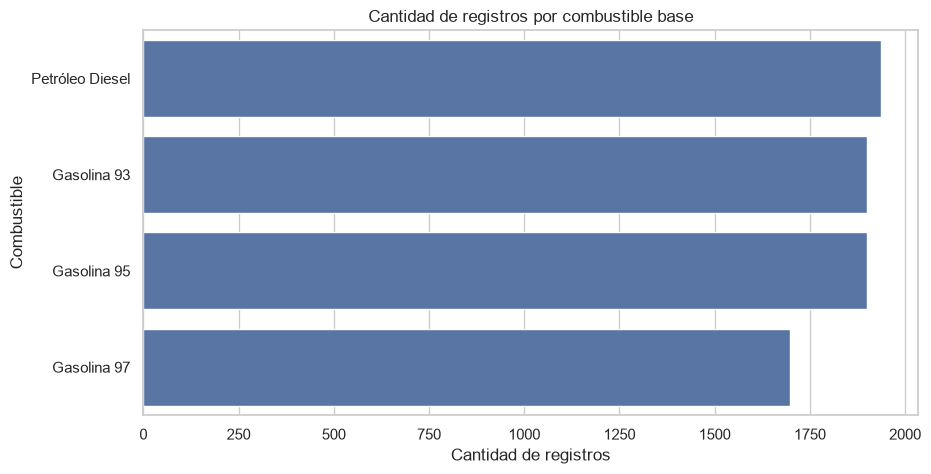

In [109]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_combustible_base,
    y="combustible_base",
    x="registros",
)

plt.title("Cantidad de registros por combustible base")
plt.xlabel("Cantidad de registros")
plt.ylabel("Combustible")
plt.show()

### Interpretación

Los combustibles con mayor cantidad de registros tienen mejor cobertura para análisis comparativos. Los combustibles con pocos registros deben interpretarse con cuidado, porque sus precios pueden depender de pocas estaciones.

## 10. Distribución de precios

Se revisa la distribución de precios después de la limpieza. Esta sección permite confirmar que los valores extremos ya no dominan los gráficos.

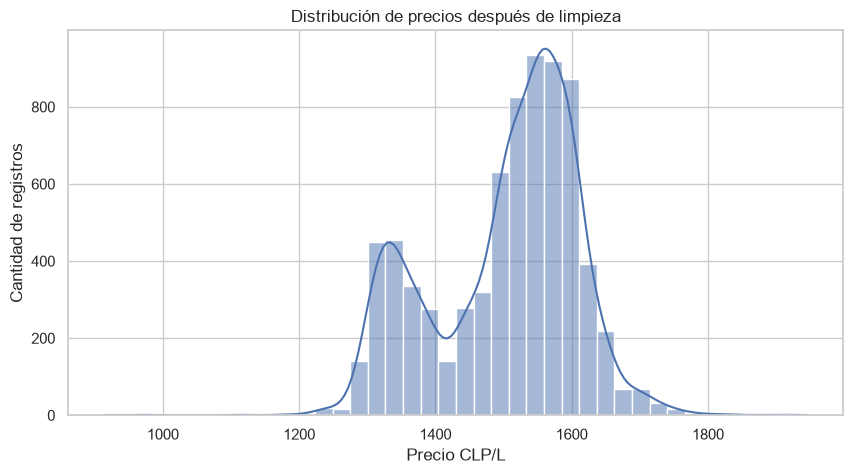

In [110]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_eda,
    x="precio",
    bins=40,
    kde=True,
)

plt.title("Distribución de precios después de limpieza")
plt.xlabel("Precio CLP/L")
plt.ylabel("Cantidad de registros")
plt.show()

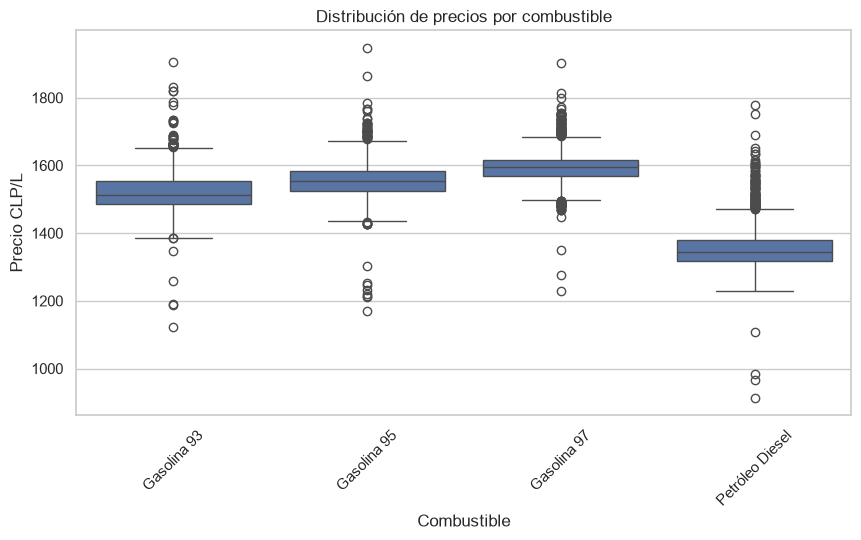

In [111]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_eda,
    x="combustible_base",
    y="precio",
)

plt.title("Distribución de precios por combustible")
plt.xlabel("Combustible")
plt.ylabel("Precio CLP/L")
plt.xticks(rotation=45)
plt.show()

## 11. Cobertura geográfica

Se analiza la cantidad de estaciones, comunas y registros por región. Esto permite evaluar en qué zonas la app tendrá mejor cobertura.

In [112]:
cobertura_region = (
    df_eda
    .groupby("region", as_index=False)
    .agg(
        registros=("precio", "count"),
        estaciones=("codigo_estacion", "nunique"),
        comunas=("comuna", "nunique"),
        precio_promedio=("precio", "mean"),
    )
    .sort_values("estaciones", ascending=False)
)

cobertura_region

,region,registros,estaciones,comunas,precio_promedio
12,Metropolitana de Santiago,2297,489,52,"1,466.79"
14,Valparaíso,807,189,36,"1,494.48"
10,Del Maule,585,156,30,"1,490.58"
8,Del Biobío,672,156,29,"1,487.07"
5,De la Araucanía,546,134,31,"1,517.16"
9,Del Libertador Gral. Bernardo O’Higgins,477,122,31,"1,517.45"
6,De los Lagos,481,113,26,"1,547.06"
4,Coquimbo,348,85,12,"1,543.37"
15,Ñuble,281,72,19,"1,491.99"
7,De los Ríos,199,50,12,"1,542.90"


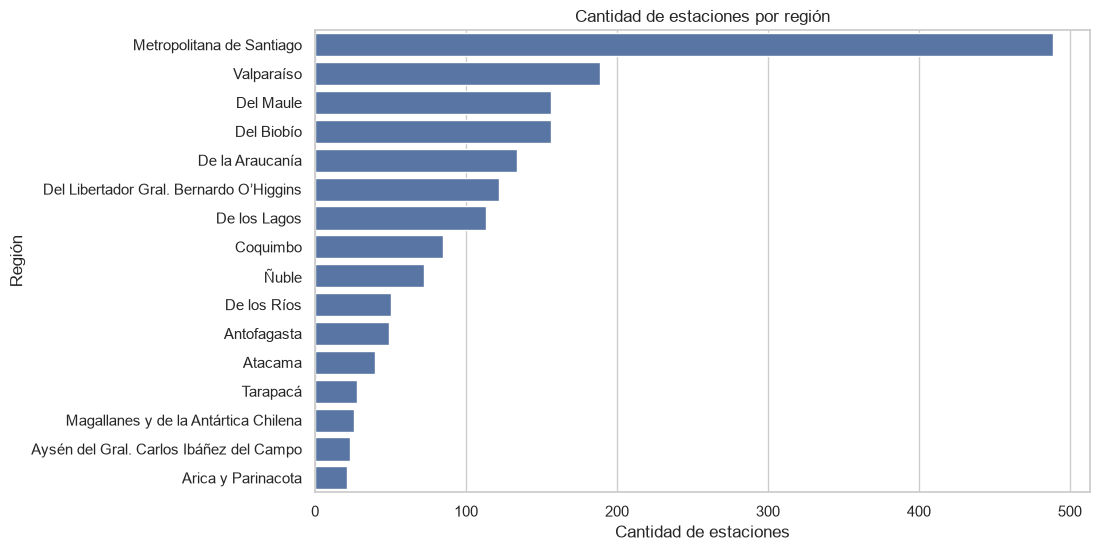

In [113]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cobertura_region,
    y="region",
    x="estaciones",
)

plt.title("Cantidad de estaciones por región")
plt.xlabel("Cantidad de estaciones")
plt.ylabel("Región")
plt.show()

### Interpretación

Las regiones con más estaciones tienen mejor cobertura para realizar comparaciones. En regiones con pocos datos, los promedios y rankings deben interpretarse con mayor cuidado.

## 12. Precio promedio por región y combustible

Se comparan precios promedio por región y combustible, evitando mezclar combustibles con escalas distintas.

In [114]:
tabla_region_combustible = (
    df_eda
    .groupby(["region", "combustible_base"], as_index=False)
    .agg(
        precio_promedio=("precio", "mean"),
        registros=("precio", "count"),
        estaciones=("codigo_estacion", "nunique"),
    )
)

tabla_region_combustible.head()

,region,combustible_base,precio_promedio,registros,estaciones
0,Antofagasta,Gasolina 93,"1,594.36",53,49
1,Antofagasta,Gasolina 95,"1,624.21",53,49
2,Antofagasta,Gasolina 97,"1,652.42",53,49
3,Antofagasta,Petróleo Diesel,"1,412.55",53,49
4,Arica y Parinacota,Gasolina 93,"1,578.57",14,14


In [115]:
pivot_region_combustible = tabla_region_combustible.pivot(
    index="region",
    columns="combustible_base",
    values="precio_promedio",
)

pivot_region_combustible

combustible_base,Gasolina 93,Gasolina 95,Gasolina 97,Petróleo Diesel
region,,,,
Antofagasta,"1,594.36","1,624.21","1,652.42","1,412.55"
Arica y Parinacota,"1,578.57","1,604.12","1,634.29","1,374.71"
Atacama,"1,572.90","1,606.10","1,637.50","1,403.90"
Aysén del Gral. Carlos Ibáñez del Campo,"1,628.81","1,665.43","1,699.84","1,512.65"
Coquimbo,"1,561.82","1,596.88","1,630.47","1,393.66"
De la Araucanía,"1,539.18","1,567.48","1,605.87","1,365.25"
De los Lagos,"1,566.62","1,599.83","1,625.09","1,400.20"
De los Ríos,"1,568.16","1,601.25","1,624.47","1,393.68"
Del Biobío,"1,506.85","1,541.89","1,578.17","1,333.89"


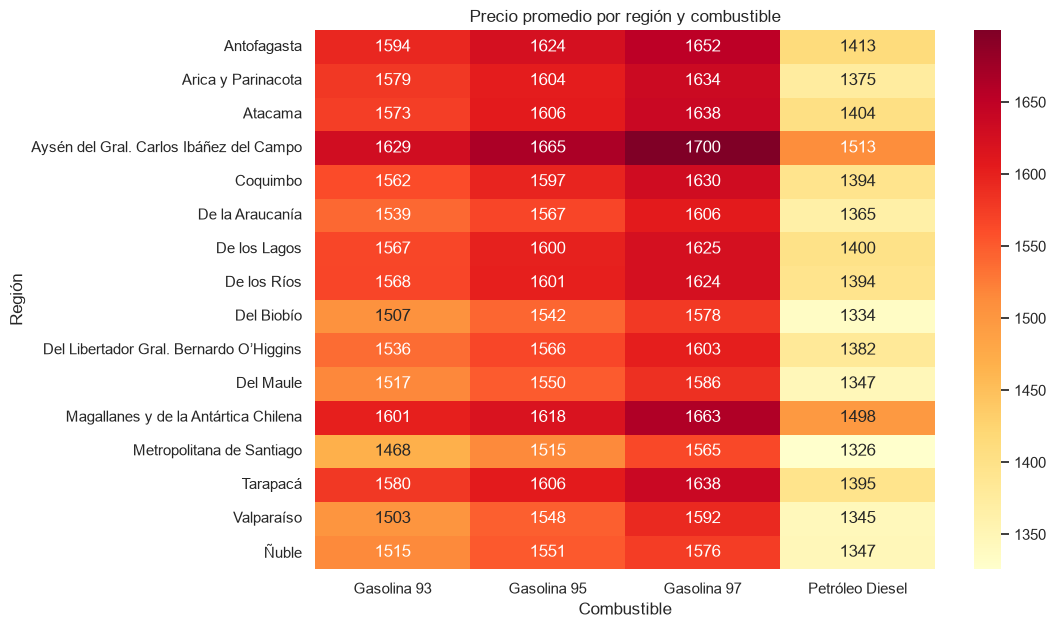

In [116]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    pivot_region_combustible,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
)

plt.title("Precio promedio por región y combustible")
plt.xlabel("Combustible")
plt.ylabel("Región")
plt.show()

## 13. Análisis por comuna y combustible

En esta sección se analiza el comportamiento de precios para cada combinación de comuna y combustible. Esto es importante porque no se deben mezclar combustibles distintos en una misma comparación.

Para cada comuna y combustible se calcula:

- cantidad de registros;
- cantidad de estaciones distintas;
- precio promedio;
- precio mínimo;
- precio máximo;
- brecha de precio entre la estación más cara y la más barata.

La brecha de precio servirá después para identificar oportunidades de ahorro dentro de una comuna.

In [117]:
tabla_comuna_combustible = (
    df_eda
    .groupby(["region", "provincia", "comuna", "combustible_base"], as_index=False)
    .agg(
        registros=("precio", "count"),
        estaciones=("codigo_estacion", "nunique"),
        precio_minimo=("precio", "min"),
        precio_promedio=("precio", "mean"),
        precio_mediano=("precio", "median"),
        precio_maximo=("precio", "max"),
    )
)

tabla_comuna_combustible["brecha_precio"] = (
    tabla_comuna_combustible["precio_maximo"]
    - tabla_comuna_combustible["precio_minimo"]
)

tabla_comuna_combustible.head()

,region,provincia,comuna,combustible_base,registros,estaciones,precio_minimo,precio_promedio,precio_mediano,precio_maximo,brecha_precio
0,Antofagasta,Antofagasta,Antofagasta,Gasolina 93,32,29,"1,569.00","1,593.34","1,586.00","1,683.00",114.00
1,Antofagasta,Antofagasta,Antofagasta,Gasolina 95,32,29,"1,602.00","1,626.47","1,619.00","1,721.00",119.00
2,Antofagasta,Antofagasta,Antofagasta,Gasolina 97,32,29,"1,630.00","1,654.88","1,647.00","1,754.00",124.00
3,Antofagasta,Antofagasta,Antofagasta,Petróleo Diesel,32,29,"1,386.00","1,412.66","1,404.00","1,520.00",134.00
4,Antofagasta,Antofagasta,Mejillones,Gasolina 93,2,2,"1,588.00","1,589.00","1,589.00","1,590.00",2.00


In [118]:
MIN_ESTACIONES_COMUNA = 5

tabla_comuna_filtrada = tabla_comuna_combustible[
    tabla_comuna_combustible["estaciones"] >= MIN_ESTACIONES_COMUNA
].copy()

print("Combinaciones comuna-combustible originales:", len(tabla_comuna_combustible))
print("Combinaciones con mínimo de estaciones:", len(tabla_comuna_filtrada))

tabla_comuna_filtrada.head()

Combinaciones comuna-combustible originales: 1210
Combinaciones con mínimo de estaciones: 404


,region,provincia,comuna,combustible_base,registros,estaciones,precio_minimo,precio_promedio,precio_mediano,precio_maximo,brecha_precio
0,Antofagasta,Antofagasta,Antofagasta,Gasolina 93,32,29,"1,569.00","1,593.34","1,586.00","1,683.00",114.00
1,Antofagasta,Antofagasta,Antofagasta,Gasolina 95,32,29,"1,602.00","1,626.47","1,619.00","1,721.00",119.00
2,Antofagasta,Antofagasta,Antofagasta,Gasolina 97,32,29,"1,630.00","1,654.88","1,647.00","1,754.00",124.00
3,Antofagasta,Antofagasta,Antofagasta,Petróleo Diesel,32,29,"1,386.00","1,412.66","1,404.00","1,520.00",134.00
12,Antofagasta,El Loa,Calama,Gasolina 93,11,10,"1,585.00","1,607.36","1,600.00","1,690.00",105.00


## 14. Oportunidades de ahorro por comuna

La brecha de precio representa la diferencia entre la estación más cara y la más barata dentro de una misma comuna y combustible. Esta métrica puede servir como indicador de oportunidad de ahorro.

In [119]:
top_oportunidades = (
    tabla_comuna_filtrada
    .sort_values("brecha_precio", ascending=False)
    .head(20)
)

top_oportunidades[
    [
        "region",
        "comuna",
        "combustible_base",
        "precio_minimo",
        "precio_maximo",
        "brecha_precio",
        "estaciones",
        "registros",
    ]
]

,region,comuna,combustible_base,precio_minimo,precio_maximo,brecha_precio,estaciones,registros
436,Del Biobío,Cabrero,Petróleo Diesel,913.00,"1,432.00",519.00,8,8
202,De la Araucanía,Temuco,Petróleo Diesel,965.00,"1,476.00",511.00,34,41
201,De la Araucanía,Temuco,Gasolina 97,"1,230.00","1,701.00",471.00,31,38
950,Metropolitana de Santiago,Santiago Centro,Petróleo Diesel,984.00,"1,447.00",463.00,26,30
200,De la Araucanía,Temuco,Gasolina 95,"1,210.00","1,664.00",454.00,34,41
956,Metropolitana de Santiago,Ñuñoa,Gasolina 95,"1,170.00","1,618.00",448.00,22,25
218,De la Araucanía,Villarrica,Petróleo Diesel,"1,109.00","1,548.00",439.00,13,13
199,De la Araucanía,Temuco,Gasolina 93,"1,188.00","1,626.00",438.00,34,41
955,Metropolitana de Santiago,Ñuñoa,Gasolina 93,"1,124.00","1,559.00",435.00,22,25
533,Del Libertador Gral. Bernardo O’Higgins,Las Cabras,Gasolina 95,"1,246.00","1,665.00",419.00,6,6


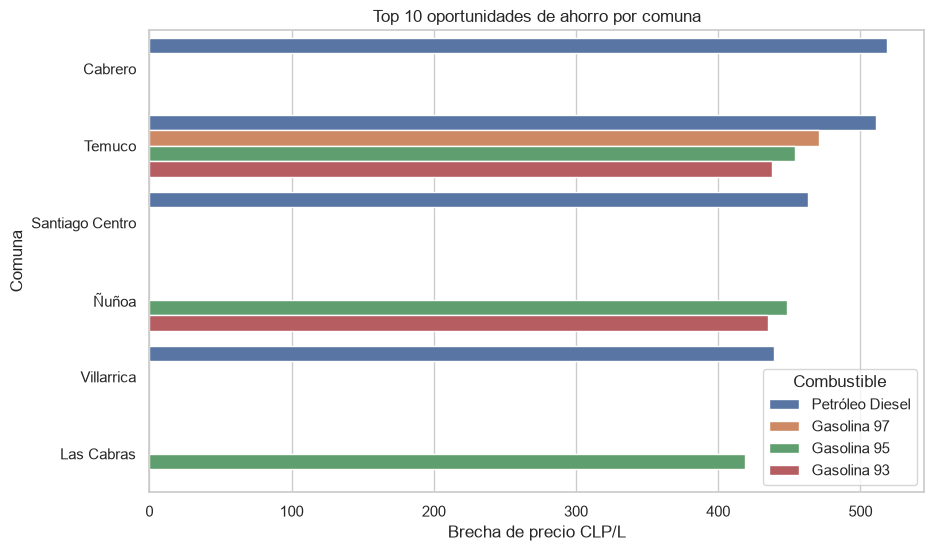

In [120]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_oportunidades.head(10),
    y="comuna",
    x="brecha_precio",
    hue="combustible_base",
)

plt.title("Top 10 oportunidades de ahorro por comuna")
plt.xlabel("Brecha de precio CLP/L")
plt.ylabel("Comuna")
plt.legend(title="Combustible")
plt.show()

### Interpretación

Las comunas con mayor brecha son especialmente relevantes para la app, porque indican lugares donde comparar estaciones puede generar una diferencia real para el usuario. Esta métrica debe mostrarse junto con el número de estaciones consideradas.

## 15. Estaciones con menores precios por combustible

Este análisis es directamente útil para la app, ya que permite mostrar rankings de estaciones más baratas según combustible y ubicación.

In [121]:
estaciones_baratas = (
    df_eda
    .sort_values(["combustible_base", "precio"])
    .groupby("combustible_base", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

columnas_estaciones = [
    "combustible_base",
    "precio",
    "distribuidor",
    "region",
    "comuna",
    "direccion",
    "tipo_atencion",
    "fecha_actualizacion",
    "latitud",
    "longitud",
]
columnas_estaciones = [col for col in columnas_estaciones if col in estaciones_baratas.columns]

estaciones_baratas[columnas_estaciones]

,combustible_base,precio,distribuidor,region,comuna,direccion,tipo_atencion,fecha_actualizacion,latitud,longitud
0,Gasolina 93,"1,124.00",DELPA,Metropolitana de Santiago,Ñuñoa,José Pedro Alessandri 1039,Asistido,2026-02-12,-33.46,-70.60
1,Gasolina 93,"1,188.00",COPEC,De la Araucanía,Temuco,General Mackenna 725,Asistido,2026-01-29,-38.74,-72.59
2,Gasolina 93,"1,192.00",GASOLINERA MAKAL,Del Biobío,Cabrero,Camino a Quinel Km 4.5,Asistido,2026-03-05,-37.00,-72.44
3,Gasolina 93,"1,259.00",PETROPRIX,Metropolitana de Santiago,Santiago Centro,MANUEL ANTONIO MATTA 380,Asistido,2025-01-09,-33.46,-70.64
4,Gasolina 93,"1,348.00",COPEC,Del Libertador Gral. Bernardo O’Higgins,Navidad,Ignacio Carrera Pinto 0,Asistido,2026-06-18,-33.95,-71.74
5,Gasolina 93,"1,385.00",JLC,Metropolitana de Santiago,Quinta Normal,VARGAS FONTECILLA 4193,Asistido,2026-06-18,-33.43,-70.69
6,Gasolina 93,"1,385.00",JLC,Metropolitana de Santiago,San Bernardo,SANTA MARGARITA 081,Asistido,2026-06-18,-33.53,-70.70
7,Gasolina 93,"1,386.00",COPEC,Metropolitana de Santiago,Maipú,Avenida Pajaritos 5200,Autoservicio,2026-06-18,-33.47,-70.74
8,Gasolina 93,"1,386.00",COPEC,Metropolitana de Santiago,Quinta Normal,San Pablo 4383,Autoservicio,2026-06-18,-33.44,-70.69
9,Gasolina 93,"1,389.00",COPEC,Metropolitana de Santiago,Estación Central,Ecuador 4603,Autoservicio,2026-06-18,-33.45,-70.70


## 16. Análisis por distribuidor

Se analiza el precio promedio por distribuidor. Este análisis es exploratorio, ya que las diferencias pueden estar influenciadas por la ubicación de las estaciones y no solo por la marca.

In [122]:
resumen_distribuidor = (
    df_eda
    .groupby("distribuidor", as_index=False)
    .agg(
        registros=("precio", "count"),
        estaciones=("codigo_estacion", "nunique"),
        regiones=("region", "nunique"),
        comunas=("comuna", "nunique"),
        precio_minimo=("precio", "min"),
        precio_promedio=("precio", "mean"),
        precio_maximo=("precio", "max"),
    )
)

MIN_ESTACIONES_DISTRIBUIDOR = 10

resumen_distribuidor_filtrado = resumen_distribuidor[
    resumen_distribuidor["estaciones"] >= MIN_ESTACIONES_DISTRIBUIDOR
].sort_values("precio_promedio")

resumen_distribuidor_filtrado

,distribuidor,registros,estaciones,regiones,comunas,precio_minimo,precio_promedio,precio_maximo
63,HN,48,16,4,13,"1,299.00","1,447.23","1,567.00"
53,FACAZ,41,14,2,12,"1,316.00","1,481.34","1,670.00"
106,SHELL,2143,454,16,180,"1,230.00","1,497.95","1,799.00"
36,COPEC,3086,707,16,263,965.00,"1,503.20","1,813.00"
62,GULF,46,14,5,13,"1,316.00","1,513.50","1,718.00"
7,ARAMCO,1306,301,16,137,"1,241.00","1,514.45","1,787.00"
107,SIN BANDERA,234,78,12,62,"1,109.00","1,514.74","1,947.00"


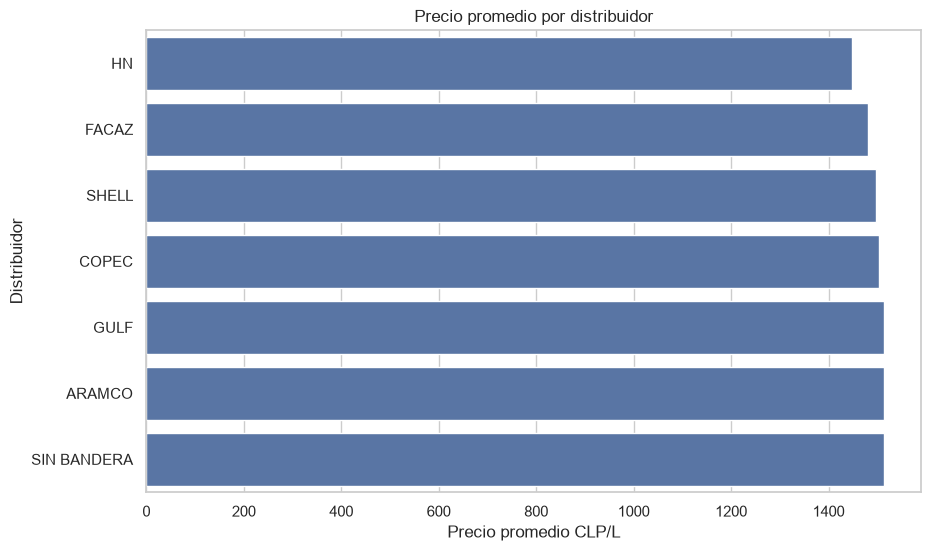

In [123]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=resumen_distribuidor_filtrado.head(15),
    y="distribuidor",
    x="precio_promedio",
)

plt.title("Precio promedio por distribuidor")
plt.xlabel("Precio promedio CLP/L")
plt.ylabel("Distribuidor")
plt.show()

### Interpretación

El análisis por distribuidor debe interpretarse con cautela. Una marca puede parecer más cara o más barata porque opera en comunas o regiones distintas. Por eso este resultado es útil como exploración, pero no como conclusión causal.

## 17. Insumos para Streamlit

A partir del EDA, se identifican variables y tablas útiles para construir la aplicación.

In [124]:
insumos_streamlit = {
    "filtros": [
        "region",
        "comuna",
        "combustible_base",
        "distribuidor",
        "tipo_atencion",
    ],
    "kpis": [
        "precio_minimo",
        "precio_promedio",
        "precio_maximo",
        "cantidad_estaciones",
    ],
    "rankings": [
        "estaciones_mas_baratas",
        "comunas_con_mayor_brecha",
        "precio_por_distribuidor",
    ],
    "mapa": [
        "latitud",
        "longitud",
        "precio",
        "direccion",
        "distribuidor",
    ],
}

insumos_streamlit

{'filtros': ['region',
  'comuna',
  'combustible_base',
  'distribuidor',
  'tipo_atencion'],
 'kpis': ['precio_minimo',
  'precio_promedio',
  'precio_maximo',
  'cantidad_estaciones'],
 'rankings': ['estaciones_mas_baratas',
  'comunas_con_mayor_brecha',
  'precio_por_distribuidor'],
 'mapa': ['latitud', 'longitud', 'precio', 'direccion', 'distribuidor']}

## 18. Exportación del dataset limpio

Se exporta `dataset_limpio.csv` actualizado para que sea simple de usar en `app.py`.

La versión exportada:

- corrige directamente `distribuidor`, unificando `SIN BANDERA` y `Sin Bandera` como `SIN BANDERA`;
- corrige directamente `precio` para los casos mayores a $10.000, dividiendo por 10;
- excluye combustibles fuera del alcance inicial de la app: GNC, GLP y Kerosene;
- excluye precios sospechosos que no tienen una corrección confiable;
- no incluye columnas auxiliares del EDA, como `precio_original`, `ajuste_precio`, `combustible_en_alcance` o `precio_valido_analisis`.

Antes de sobrescribir el archivo, se guarda una copia de respaldo con el nombre `dataset_limpio_backup_eda.csv`.


In [126]:
OUTPUT_PATH = DATA_DIR / "dataset_limpio.csv"

# Dataset final simple para la app:
# - solo registros válidos para análisis/app;
# - sin columnas auxiliares del EDA.
columnas_auxiliares_eda = [
    "precio_original",
    "ajuste_precio",
    "combustible_en_alcance",
    "precio_valido_analisis",
    "distribuidor_normalizado_temp",
]

df_export = df_limpio[df_limpio["precio_valido_analisis"]].copy()
df_export = df_export.drop(
    columns=[col for col in columnas_auxiliares_eda if col in df_export.columns]
)

# Exportar dataset limpio actualizado.
df_export.to_csv(OUTPUT_PATH, index=False)

print("Dataset limpio actualizado en:", OUTPUT_PATH)
print("Filas originales:", df.shape[0])
print("Filas exportadas:", df_export.shape[0])
print("Columnas exportadas:", df_export.shape[1])

print("\nDistribuidores con 'Bandera' exportados:")
display(
    df_export[
        df_export["distribuidor"].astype(str).str.contains("BANDERA", case=False, na=False)
    ]["distribuidor"].drop_duplicates()
)

print("\nCombustibles exportados:")
display(df_export["combustible_base"].value_counts())


Dataset limpio actualizado en: ..\data\dataset_limpio.csv
Filas originales: 8580
Filas exportadas: 7436
Columnas exportadas: 21

Distribuidores con 'Bandera' exportados:


146    SIN BANDERA
Name: distribuidor, dtype: str


Combustibles exportados:


combustible_base
Petróleo Diesel    1938
Gasolina 93        1901
Gasolina 95        1899
Gasolina 97        1698
Name: count, dtype: int64

## 19. Conclusiones del EDA

- El dataset contiene información útil para construir una aplicación de comparación de precios de combustibles.
- Se detectaron precios mayores a $10.000 CLP/L, los cuales fueron tratados como posibles errores de digitación decimal y corregidos dividiendo por 10.
- Se detectaron diferencias de escritura en la categoría `Sin Bandera`, por lo que la columna `distribuidor` se estandarizó directamente para evitar duplicidades en filtros y gráficos.
- GNC, GLP y Kerosene quedaron fuera del alcance inicial de la aplicación, por lo que no se exportan en el dataset final usado por `app.py`.
- Los precios demasiado bajos dentro del alcance, como el caso sospechoso de Petróleo Diésel, se excluyen del dataset final porque no existe una regla segura para corregirlos.
- Los análisis comparativos se realizaron con `df_eda`, filtrando precios válidos entre $500 y $3000.
- Las variables más relevantes para la aplicación son región, comuna, combustible, distribuidor, precio, dirección, latitud y longitud.
- Para rankings por comuna se recomienda exigir un mínimo de estaciones, evitando conclusiones basadas en pocos registros.
- La aplicación debería priorizar filtros por ubicación y combustible, rankings de estaciones más baratas, mapa de estaciones y oportunidades de ahorro por comuna.


## 20. Próximos pasos

1. Revisar que `dataset_limpio.csv` actualizado sea leído correctamente por `app.py`.
2. Confirmar que la app ya no muestre GNC, GLP ni Kerosene si esos combustibles quedan fuera del alcance inicial.
3. Confirmar que el filtro de distribuidor muestre solo `SIN BANDERA`, y no dos variantes separadas.
4. Mostrar en la app la fecha máxima de actualización de los datos.
5. Agregar filtros por región, comuna, combustible y distribuidor.
6. Usar latitud y longitud para construir el mapa de estaciones.
7. Documentar en el README la regla de limpieza aplicada sobre precios extremos y combustibles excluidos.
